<center><h1><font color='darkblue'>Elektrotehnički fakultet Beograd</font></h1></center>

# Modeli u biologiji

Luka Puco 24/0091

<font color='red'>
Preimenovati svesku: File/Rename u [2] biologija_ime_prezime<br>
Redovno snimati aktuelnu verziju sveske: File/Save and Checkpoint <br>
Preuzimanje fajla: Download as Notebook (.ipynb)</font>

#### __Zadatak 1__: Eksponencijalni i logistički rast
Uporediti model eksponencijalnog i logističkog porasta. Diferencijalne jednačine koje definišu ova dva procesa su:<br><br>Eksponencijalni porast:<br><br> $\frac{dx}{dt} = rx$, <br><br>Logistički porast:<br> <br>$\frac{dx}{dt} = rx(1-\frac{x}{K})$, <br><br> gde su $r$ i $K$ stopa porasta i nosivi kapacitet, respektivno, prema definicijama sa slajdova. 

a) Formirati Python skriptu koja na vremenskom domenu od 0 do 70 dana (vremensku osu napraviti kao ekvidistantnu podelu u 1000 tačaka), rešava diferencijalnu jednačinu eksponencijalnog rasta kao i jednačinu logističkog rasta. Jednačine treba rešiti za početni uslov $x(0) = 50$ jedinki, za tri slučaja stope rasta $r = 0.1, 0.2, 0.3$ jedinki na dan. U slučaju logističkog rasta, nosivi kapacitet iznosi $K = 500$ jedinki. 

Nacrtati dva grafika:

grafik 1: Reprodukovati levi grafik sa slajda br. 4 iz pripremnog fajla. Na istom grafiku prikazati:<br>
<ol>
<li>Sve tri krive (za sve tri vrednosti stope rasta $r$) koje predstavljaju rešenja diferencijalne jednačine logističkog rasta. Krive treba da budu nacrtane različitim bojama, za koje treba prikazati legendu.</li> 
<li>Dodati horizontalnu isprekidanu liniju crvene boje $x  = K$ (asimptotu kojoj teže sve tri dinamike).</li>
<li>Označiti ose. Dodati grid na grafik.</li>
</ol>

grafik 2: Reprodukovati desni grafik sa slajda br. 4 iz pripremnog fajla koji poredi eksponencijalni porast sa logističkim porastom. Na istom grafiku prikazati:
<ol>
<li>Sve tri krive (za sve tri vrednosti stope rasta $r$) koje predstavljaju rešenja diferencijalne jednačine logističkog rasta. Krive treba da budu nacrtane različitim bojama, za koje treba prikazati legendu.</li> 
<li>Sve tri krive (za sve tri vrednosti stope rasta $r$) koje predstavljaju rešenja diferencijalne jednačine eksponencijalnog rasta. Sve tri krive treba da budu nacrtane sivom bojom kao isprekidane linije.</li>
<li>Dodati horizontalnu isprekidanu liniju crvene boje $x  = K$ (asimptotu kojoj teže sve tri dinamike).</li>
<li>Označiti ose. Dodati grid na grafik.</li> 
</ol>    
Da bi grafik bio pregledan (zbog velikog porasta eksponencijalne funkcije), postaviti limit za $y$ osu grafika tako da ide od 0 do 600, pomoću naredbe <font color='blue'>plt.ylim((0,600))</font>. 

Text(0, 0.5, 'x(t)')

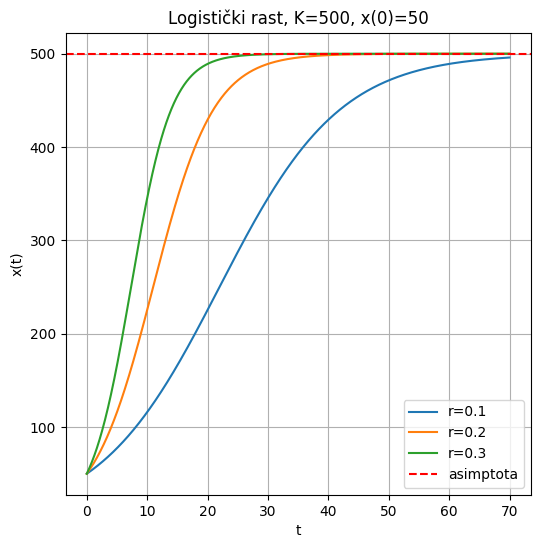

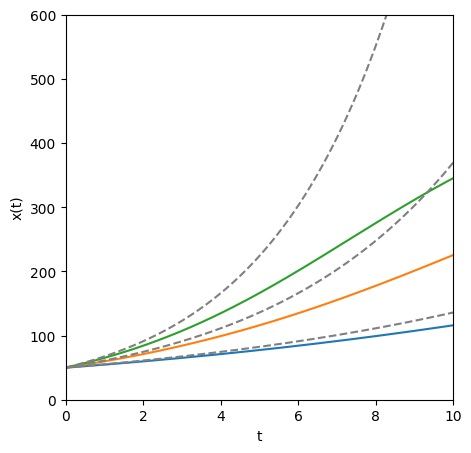

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

def expgrowth(x, t, r):
    return r * x

def loggrowth(x, t, r, K):
    return r * x * (1 - x/K)

vreme = np.linspace(0, 70, 1000)


log1 = integrate.odeint(loggrowth, 50.0, vreme, args=(0.1, 500))
log2 = integrate.odeint(loggrowth, 50.0, vreme, args=(0.2, 500))
log3 = integrate.odeint(loggrowth, 50.0, vreme, args=(0.3, 500))

plt.figure(figsize=(6,6))
plt.plot(vreme, log1, label="r=0.1")
plt.plot(vreme, log2, label="r=0.2")
plt.plot(vreme, log3, label="r=0.3")
plt.axhline(y=500, color="red", linestyle="--", label="asimptota")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Logistički rast, K=500, x(0)=50")
plt.grid()
plt.legend()

plt.figure(figsize=(5,5))

eksp1=integrate.odeint(expgrowth,50.0,vreme,args=(0.1,))
eksp2=integrate.odeint(expgrowth,50.0,vreme,args=(0.2,))
eksp3=integrate.odeint(expgrowth,50.0,vreme,args=(0.3,))
plt.plot(vreme, log1, label="r=0.1")
plt.plot(vreme, log2, label="r=0.2")
plt.plot(vreme, log3, label="r=0.3")
plt.plot(vreme,eksp1,color="grey",linestyle="--")
plt.plot(vreme,eksp2,color="grey",linestyle="--")
plt.plot(vreme,eksp3,color="grey",linestyle="--")
plt.ylim((0,600))
plt.xlim((0,10))
plt.xlabel("t")
plt.ylabel("x(t)")


b) Zašto se eksponencijalni i logistički brže razilaze kada je stopa rasta $r$ veća? 

Kad je r vece, logisticki rast ima jacu kocnicu, pa brze stigne do ogranicenja K i izravna se. Eksponencijalni nema kocnicu, pa nastavlja da bezi navise. Zato se za vece r krive brze razilaze.

c) Napraviti novu Python skriptu koja učitava fajl sunflower_data.csv i kroz eksperimentalne podatke provlači eksponencijalni i logistički model (reprodukovati grafik za slajda br. 6 u pripremnom fajlu).<br>

Skica postupka: Pomoću naredbe <font color='blue'>pd.read_csv</font> učitati fajl sunflower_data.csv. Nacrtati grafik zavisnosti kolone Height od kolone Age, pri čemu grafik treba da bude tipa scatter, sa markerima tamno crvene boje (DarkRed), veličine 10. 
Zatim, za $r = 0.1$ rešiti diferencijalne jednačine eksponencijalnog i logističkog rasta i dodati te dve krive na postojeći grafik. Uneti legendu, obeležiti ose grafika, postaviti grid, a limit za y osu postaviti da bude od 0 do 280. Vremensku osu napraviti od $tmin$ do $tmax$ u 200 tačaka. Za $tmin$ uzeti minimalni element kolone Age, za $tmax$ uzeti maksimalni element kolone Age. Za vrednost nosivog kapaciteta $K$, uzeti maksimalni element kolone Height. Za početni uslov $x(0)$ uzeti prvi element kolone Height koji odgovara prvom vremenskom trenutku za koji imamo podatke. 

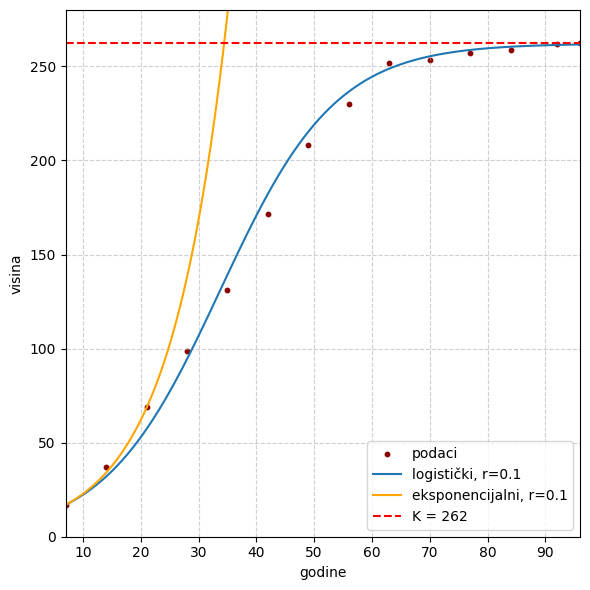

In [10]:
import pandas as pd
df=pd.read_csv("sunflower_data.csv")
ma=df["Age"].max()
mi=df["Age"].min()
vreme=np.linspace(mi,ma,200)
K=df["Height"].max()
i = df["Age"].idxmin()
x0 = df.loc[i, "Height"]

r = 0.1
t = vreme
tmin, tmax = mi, ma

x_exp = integrate.odeint(expgrowth, x0, t, args=(r,))
x_log = integrate.odeint(loggrowth, x0, t, args=(r, K))

plt.figure(figsize=(6,6))


plt.scatter(df["Age"], df["Height"], c="darkred", s=10, label="podaci")

plt.plot(t, x_log, label="logistički, r=0.1")
plt.plot(t, x_exp,color="orange", label="eksponencijalni, r=0.1")


plt.axhline(K, color="red", linestyle="--", label=f"K = {K:.0f}")

plt.xlabel("godine")
plt.ylabel("visina")
plt.ylim(0, 280)
plt.xlim(tmin, tmax)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

d) Sa grafika oceniti vremenski trenutak do koga eksponencijalni model dovoljno dobro prati eksperimentalne podatke.

do dvadeset i druge godine.

***
<font color='red'>Snimiti aktuelnu verziju sveske: File/Save and Checkpoint <br>
***

#### __Zadatak 2__: Lotka-Volterra model

a) U okviru nove Python skripte formirati Python funkciju koja predstavlja sistem diferencijalih jednačina koje odgovaraju Lotka-Volterra modelu bez logističkog rasta prey vrste (lovine):

<br>$\frac{dx}{dt} = r_{prey}x - axy$<br>
<br>$\frac{dy}{dt} = -r_{predator}y + bxy$



Pomoću pandas biblioteke učitati fajl (lvm_data.csv) sa eksperimentalnim podacima o zečevima i lisicama. Na osnovu eksperimentalnih podataka dolazi se do sledećih vrednosti za parametre Lotka-Volterra sistema jednačina: $r_{prey} = 0.4807$, $a = 0.02482$, $r_{predator} = 0.9272$, $b = 0.02756$. Po uzoru na zadatak sa rastom suncokretove stabljike, zaključiti kako treba napraviti vremensku osu i postaviti početne uslove.

Nacrtati grafik na kome treba prikazati eksperimentalne podatke za zečeve (scatter plot, DarkRed tačke veličine 10) i krivu dinamike zečeva koja se dobija iz rešavanja Lotka-Volterra sistema (reprodukovati grafik sa slajda br. 10 iz pripremnog fajla). Označiti ose, postaviti grid i staviti legendu. 


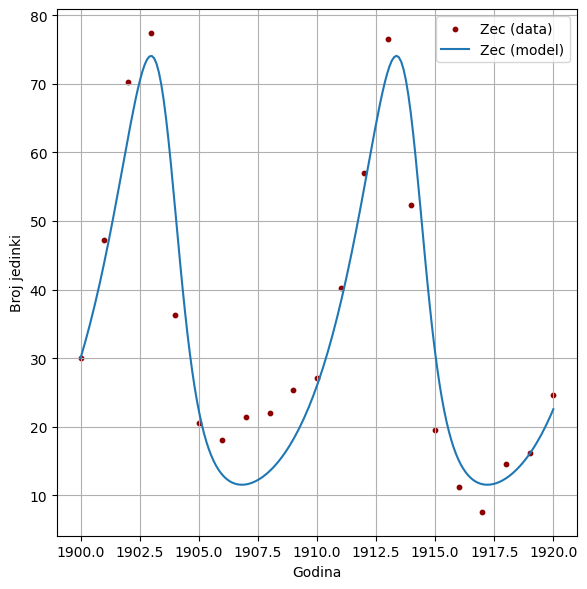

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

def LVM(z, t, r_prey, r_predator, a, b):
    x, y = z
    return [r_prey*x - a*x*y, -r_predator*y + b*x*y]

df = pd.read_csv("lvm_data.csv")

mi = df["Godina"].min()
ma = df["Godina"].max()
i0 = df["Godina"].idxmin()
vreme = np.linspace(mi, ma, 200)

r_prey = 0.4807
a = 0.02482
r_predator = 0.9272
b = 0.02756

x0 = df.loc[i0, "Zec"] 
y0 = df.loc[i0, "Lisica"]
z0 = [x0, y0]

resenje = integrate.odeint(LVM, z0, vreme, args=(r_prey, r_predator, a, b))
zec_model = resenje[:, 0]

plt.figure(figsize=(6,6))
plt.scatter(df["Godina"], df["Zec"], c="DarkRed", s=10, label="Zec (data)")
plt.plot(vreme, zec_model, label="Zec (model)")
plt.xlabel("Godina")
plt.ylabel("Broj jedinki")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Nacrtati grafik na kome treba prikazati eksperimentalne podatke za lisice (scatter plot, DarkRed tačke veličine 10) i krivu dinamike lisica koja se dobija iz rešavanja Lotka-Volterra sistema (reprodukovati grafik sa slajda br. 11 iz pripremnog fajla). Označiti ose, postaviti grid i staviti legendu.

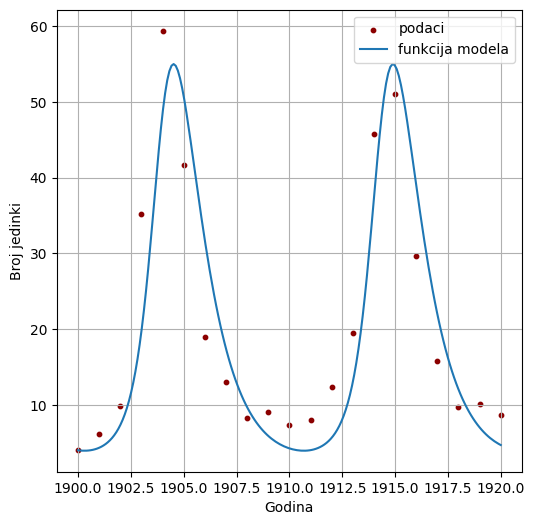

In [9]:
lisica=resenje[:,1]
plt.figure(figsize=(6,6))
plt.scatter(df["Godina"], df["Lisica"], c="DarkRed", s=10, label="podaci")
plt.plot(vreme,lisica,label = "funkcija modela")
plt.xlabel("Godina")
plt.ylabel("Broj jedinki")
plt.grid(True)
plt.legend()

Nacrtati grafik na kome treba prikazati krive dinamike zečeva i lisica koje se dobijaju iz rešavanja Lotka-Volterra sistema na novoj vremenskoj skali koja je produžena za još 50 godina u odnosu na prethodnu (reprodukovati grafik sa slajda br. 12 iz pripremnog fajla). Označiti ose, postaviti grid i staviti legendu. 

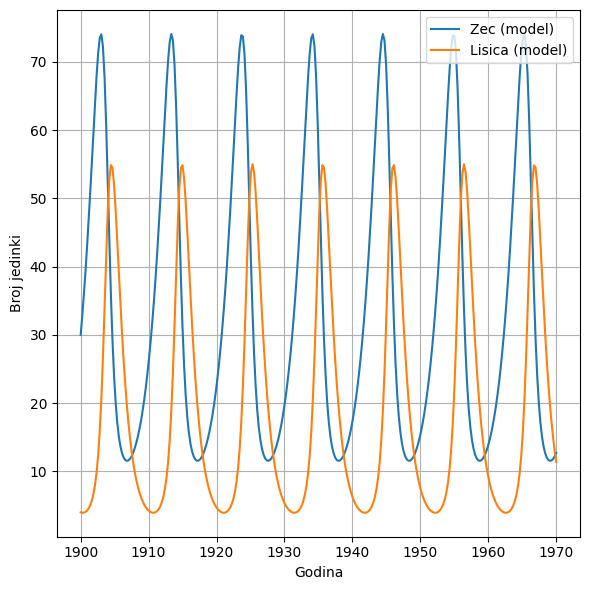

In [ ]:
x0 = df.loc[i0, "Zec"]
y0 = df.loc[i0, "Lisica"]
z0 = [x0, y0]
vreme_ext = np.linspace(mi, ma + 50, 300)

res_ext = integrate.odeint(LVM, z0, vreme_ext, args=(r_prey, r_predator, a, b))
zec  = res_ext[:, 0]
lis  = res_ext[:, 1]

plt.figure(figsize=(6,6))
plt.plot(vreme_ext, zec, label="Zec (model)")
plt.plot(vreme_ext, lis, label="Lisica (model)")
plt.xlabel("Godina")
plt.ylabel("Broj jedinki")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Proceniti ugaonu frekvenciju oscilovanja lisica, kao i zečeva i proveriti da li se slaže sa formulom datom na slajdu br. 12 iz pripremnog fajla.

na grafiku se vidi da je period 10 godina, isti je za lisice i za zeceve. w=2pi/T=0,66. a po formuli ispada da je w=sqrt(r_prey*r_predator)=0.66

Nacrtati fazni dijagram koji odgovara prethodnom vremenskom dijagramu (reprodukovati grafik sa slajda br. 13 iz pripremnog fajla). Označiti ose i postaviti grid. Uneti verikalnu i horizonatlnu isprekidanu liniju crvene boje, tako da se u preseku definiše stacionarno stanje ovakvih oscilacija. 

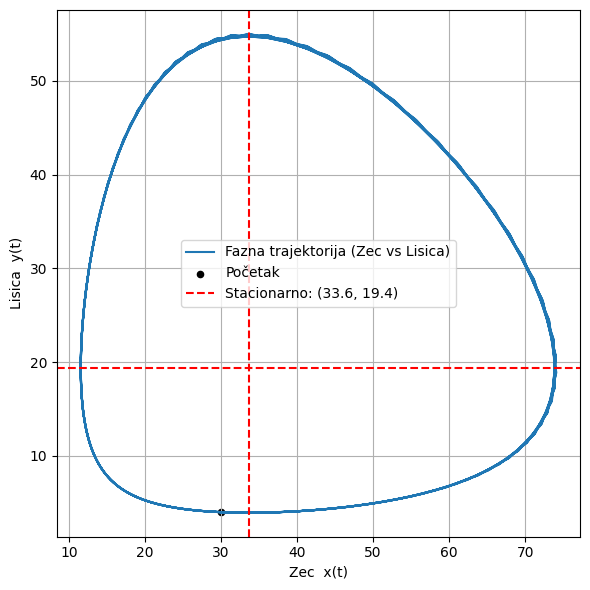

In [ ]:

zec = res_ext[:, 0]
lis = res_ext[:, 1]

x_star = r_predator / b
y_star = r_prey / a

plt.figure(figsize=(6,6))
plt.plot(zec, lis, label="Fazna trajektorija (Zec vs Lisica)")
plt.scatter([zec[0]], [lis[0]], c="k", s=20, label="Početak")


plt.axvline(x_star, color="red", linestyle="--")
plt.axhline(y_star, color="red", linestyle="--", label=f"Stacionarno: ({x_star:.1f}, {y_star:.1f})")

plt.xlabel("Zec  x(t)")
plt.ylabel("Lisica  y(t)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Kog oblika je fazni dijagram i zašto?

oblika je elipse, u okolini stacionarne tacke. Na pocetku se zecevi razmnozavaju vise od lisica do 75 hiljada, nakon toga lisice pocnu vise da se razmnozavaju pa jedu zeceve, kada broj zeceva padne krene da pada i broj lisica, a kada padne broj lisica onda raste broj zeceva i tako u krug. citanje se pocinje od Pocetne tacke (Pocetak).

b)	Simulirati Lotka-Volterra model sa logističkim rastom za $prey$ vrstu:

<br>$\frac{dx}{dt} = r_{prey}x(1-\frac{x}{K}) - axy$<br>
<br>$\frac{dy}{dt} = -r_{predator}y + \epsilon bxy$

U novoj Python skripti reprodukovati grafike sa slajda br. 15. iz pripremnog fajla. Za početne uslove koji odgovaraju početnim uslovima iz prethodnog zadatka, za parametre koji odgovaraju parametrima iz prethodnog zadatka (uz dodatak $K = 250$, $\epsilon = 0.9$), na vremenskoj skali od 1900. do 2100. godine u 1000 ekvidistantnih tačaka, rešavati sistem diferencijalnih jednačina. 

Nacrtati vremenski dijagram lisica i zečeva na kome treba označiti ose grafika, postaviti grid i uneti legendu.

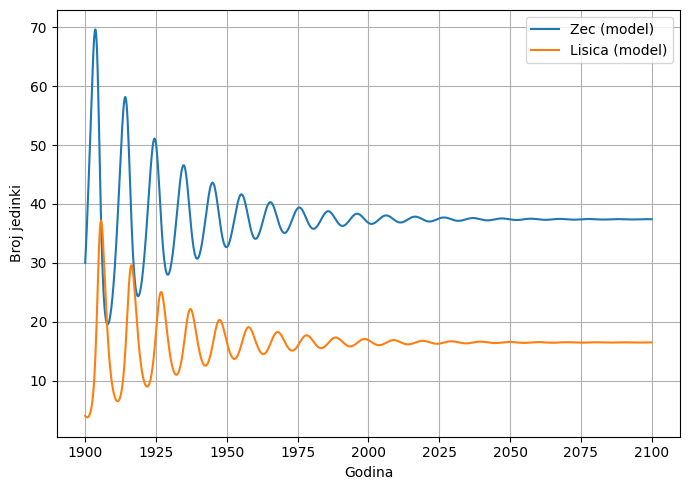

In [ ]:
def LVM_log(z, t, r_prey, r_predator, a, b, K, eps):
    x, y = z
    dxdt = r_prey * x * (1 - x / K) - a * x * y
    dydt = -r_predator * y + eps * b * x * y
    return [dxdt, dydt]

df = pd.read_csv("lvm_data.csv")

i0 = df["Godina"].idxmin()
x0 = df.loc[i0, "Zec"]
y0 = df.loc[i0, "Lisica"]
z0 = [x0, y0]

r_prey = 0.4807
a = 0.02482
r_predator = 0.9272
b = 0.02756
K = 250
eps = 0.9

t = np.linspace(1900, 2100, 1000)

res = integrate.odeint(LVM_log, z0, t, args=(r_prey, r_predator, a, b, K, eps))
zec = res[:, 0]
lis = res[:, 1]

plt.figure(figsize=(7,5))
plt.plot(t, zec, label="Zec (model)")
plt.plot(t, lis, label="Lisica (model)")
plt.xlabel("Godina")
plt.ylabel("Broj jedinki")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Nacrtati fazni dijagram dinamike lisica i zečeva, na kome treba označiti ose grafika i postaviti grid.

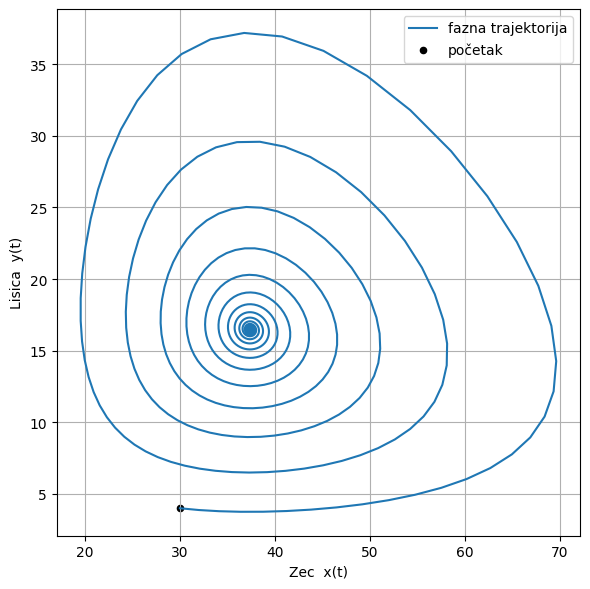

In [ ]:
zec = res[:, 0]
lis = res[:, 1]

plt.figure(figsize=(6,6))
plt.plot(zec, lis, label="fazna trajektorija")
plt.scatter([zec[0]], [lis[0]], s=20, c="k", label="početak")
plt.xlabel("Zec  x(t)")
plt.ylabel("Lisica  y(t)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Kog oblika je fazni dijagram i zašto?

spirala ka ravnotezi se smanjuje zbog prigusenja. malo lisica zecevi rastu, sa zakasnjenjem porastu lisice. mnogo lisica zecevi opadaju, malo zeceva lisice opadaju.

<font color='red'>Snimiti aktuelnu verziju sveske: File/Save and Checkpoint <br>
Preuzimanje fajla: Download as Notebook (.ipynb) </font>